<a href="https://colab.research.google.com/github/marco-la-rosa/tox21-toxicity-ML-classification/blob/main/tox21-toxicity-ML-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!wget https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz

df = pd.read_csv("tox21.csv.gz", compression="gzip")
df.head()

--2026-04-13 18:53:21--  https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz
Resolving deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)... 52.219.116.225, 52.219.194.162, 52.219.216.234, ...
Connecting to deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)|52.219.116.225|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122925 (120K) [application/x-gzip]
Saving to: ‘tox21.csv.gz’

tox21.csv.gz        100%[===================>] 120.04K  --.-KB/s    in 0.05s   

2026-04-13 18:53:21 (2.20 MB/s) - ‘tox21.csv.gz’ saved [122925/122925]



,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [ ]:
df.shape

(7831, 14)

In [ ]:
df.columns

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   object 
 13  smiles         7831 non-null   object 
dtypes: float64(12), object(2)
memory usage: 856.6+ KB


In [ ]:
df.isnull().sum()

,0
NR-AR,566
NR-AR-LBD,1073
NR-AhR,1282
NR-Aromatase,2010
NR-ER,1638
NR-ER-LBD,876
NR-PPAR-gamma,1381
SR-ARE,1999
SR-ATAD5,759
SR-HSE,1364


In [ ]:
counts = []
for column in df.columns[:-2]:
  not_toxic = (df[column] == 0).sum()
  toxic = (df[column] == 1).sum()

  counts.append({
      "Test": column,
      "Not Toxic": not_toxic,
      "Toxic": toxic
  })

counts_df = pd.DataFrame(counts)
print(counts_df.to_string())


             Test  Not Toxic  Toxic
0           NR-AR       6956    309
1       NR-AR-LBD       6521    237
2          NR-AhR       5781    768
3    NR-Aromatase       5521    300
4           NR-ER       5400    793
5       NR-ER-LBD       6605    350
6   NR-PPAR-gamma       6264    186
7          SR-ARE       4890    942
8        SR-ATAD5       6808    264
9          SR-HSE       6095    372
10         SR-MMP       4892    918
11         SR-p53       6351    423


<Axes: xlabel='Test'>

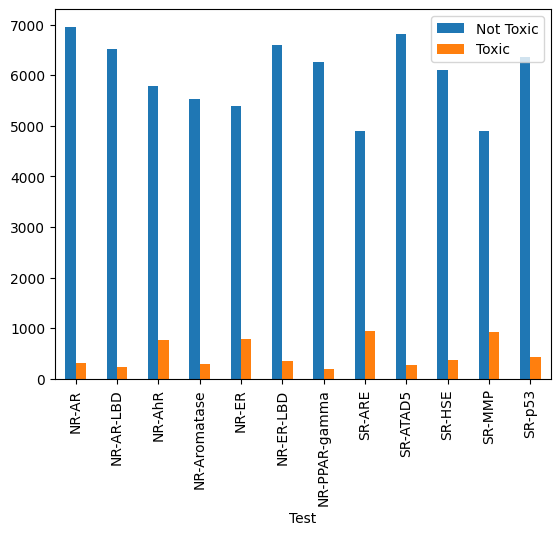

In [ ]:
counts_df.plot.bar(x="Test")